<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/Efficientnet_hybrid_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

from sklearn.metrics import classification_report,confusion_matrix

In [2]:
dataset_path1="/content/drive/MyDrive/DataSet/ArsenicSkinImageBD"

In [3]:
dataset_path2="/content/drive/MyDrive/DataSet/Original"

In [4]:
IMG_SIZE=224
BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    dataset_path1,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator=val_datagen.flow_from_directory(
    dataset_path2,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8892 images belonging to 2 classes.
Found 1287 images belonging to 2 classes.


In [5]:
input_layer=Input(shape=(224,224,3))

x=Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x=BatchNormalization()(x)
x=Conv2D(32,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(64,(3,3),activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(64,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(128,(3,3),activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=Conv2D(128,(3,3),activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(256,(3,3),activation='relu')(x)
x=BatchNormalization()(x)
x=MaxPooling2D()(x)

cnn_features=GlobalAveragePooling2D()(x)
cnn_features=Dense(256,activation='relu')(cnn_features)

In [6]:
base_model=EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable=False

y=base_model.output

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
def se_block(input_tensor,ratio=8):

    filters=input_tensor.shape[-1]

    se=GlobalAveragePooling2D()(input_tensor)
    se=Dense(filters//ratio,activation='relu')(se)
    se=Dense(filters,activation='sigmoid')(se)

    se=Reshape((1,1,filters))(se)

    return Multiply()([input_tensor,se])

In [8]:
attention=se_block(y)
attention=GlobalAveragePooling2D()(attention)

In [9]:

y=GlobalAveragePooling2D()(y)

y=Dense(512,activation='relu')(y)
y=BatchNormalization()(y)

y=Dense(256,activation='relu')(y)
y=Dropout(0.5)(y)

efficient_features=Dense(256,activation='relu')(y)

In [10]:
combined=Concatenate()([cnn_features,efficient_features,attention])

z=Dense(512,activation='relu')(combined)
z=BatchNormalization()(z)

z=Dense(256,activation='relu')(z)
z=Dropout(0.5)(z)

z=Dense(128,activation='relu')(z)
z=Dropout(0.4)(z)

output=Dense(train_generator.num_classes,activation='softmax')(z)

model=Model(inputs=input_layer,outputs=output)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,592,417 (82.37 MB)

 Trainable params: 8,748,086 (33.37 MB)

 Non-trainable params: 12,844,331 (49.00 MB)

In [12]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [13]:
EPOCHS=5

history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop,reduce_lr]
)


Epoch 1/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 6299s 22s/step - accuracy: 0.7223 - loss: 0.6074 - val_accuracy: 0.4204 - val_loss: 3.7052 - learning_rate: 0.0010
Epoch 2/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 6002s 22s/step - accuracy: 0.8110 - loss: 0.4242 - val_accuracy: 0.4235 - val_loss: 1.7916 - learning_rate: 0.0010
Epoch 3/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 6036s 22s/step - accuracy: 0.8423 - loss: 0.3635 - val_accuracy: 0.5253 - val_loss: 0.8252 - learning_rate: 0.0010
Epoch 4/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 6071s 22s/step - accuracy: 0.8616 - loss: 0.3198 - val_accuracy: 0.4507 - val_loss: 1.5617 - learning_rate: 0.0010
Epoch 5/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 6022s 22s/step - accuracy: 0.8877 - loss: 0.2756 - val_accuracy: 0.8283 - val_loss: 0.3823 - learning_rate: 0.0010


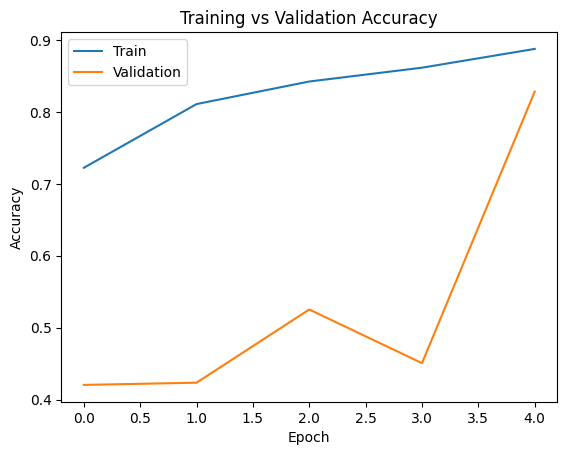

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()


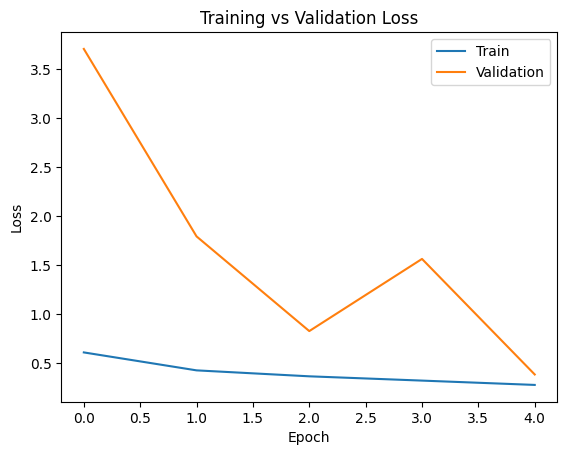

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])
plt.show()


In [16]:
loss,accuracy=model.evaluate(val_generator)

print("Test Accuracy:",accuracy)


41/41 ━━━━━━━━━━━━━━━━━━━━ 465s 11s/step - accuracy: 0.8283 - loss: 0.3823
Test Accuracy: 0.8282828330993652


In [17]:
pred=model.predict(val_generator)

y_pred=np.argmax(pred,axis=1)
y_true=val_generator.classes

print(classification_report(y_true,y_pred))

41/41 ━━━━━━━━━━━━━━━━━━━━ 466s 11s/step
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       741
           1       0.83      0.75      0.79       546

    accuracy                           0.83      1287
   macro avg       0.83      0.82      0.82      1287
weighted avg       0.83      0.83      0.83      1287



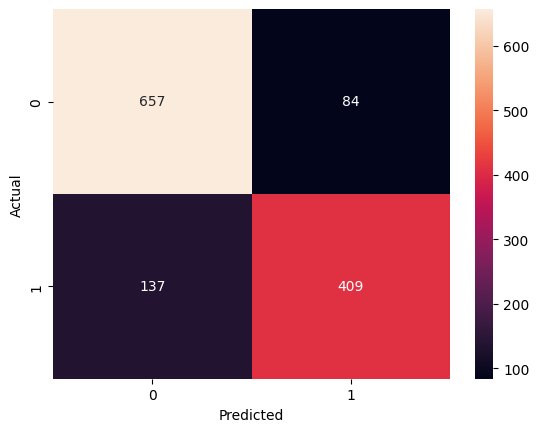

In [18]:
cm=confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


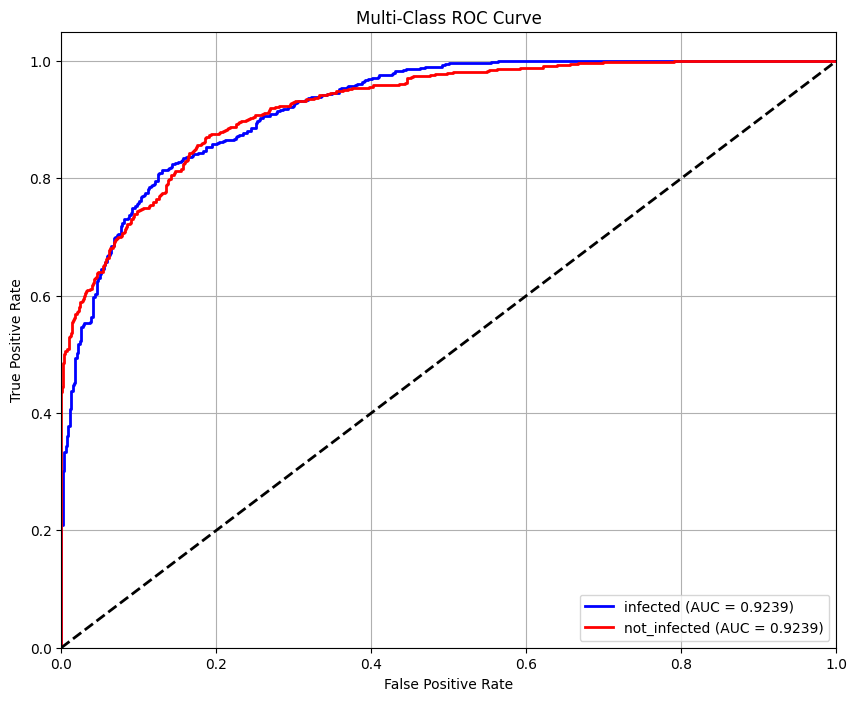

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from tensorflow.keras.utils import to_categorical
import numpy as np

# True labels
y_true = val_generator.classes

# Number of classes
n_classes = train_generator.num_classes

# Convert labels to one-hot format
y_true_bin = to_categorical(y_true, num_classes=n_classes)

# Predicted probabilities from model
y_score = pred

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

class_names = list(train_generator.class_indices.keys())

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})'
    )

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()